In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [3]:
train_df = pd.read_json('data/raw_train_data.json')
dev_df = pd.read_json('data/raw_dev_data.json')

In [9]:
train_size = train_df.shape[0]
dev_size = dev_df.shape[0]

print(f'Train size: {train_size}')
print(f'Dev size: {dev_size}')

Train size: 7000
Dev size: 1034


In [10]:
train_db_id_count = train_df['db_id'].nunique()
dev_db_id_count = dev_df['db_id'].nunique()

print(f'Train dataset number of databases: {train_db_id_count}')
print(f'Dev dataset number of databases: {dev_db_id_count}')

Train dataset number of databases: 140
Dev dataset number of databases: 20


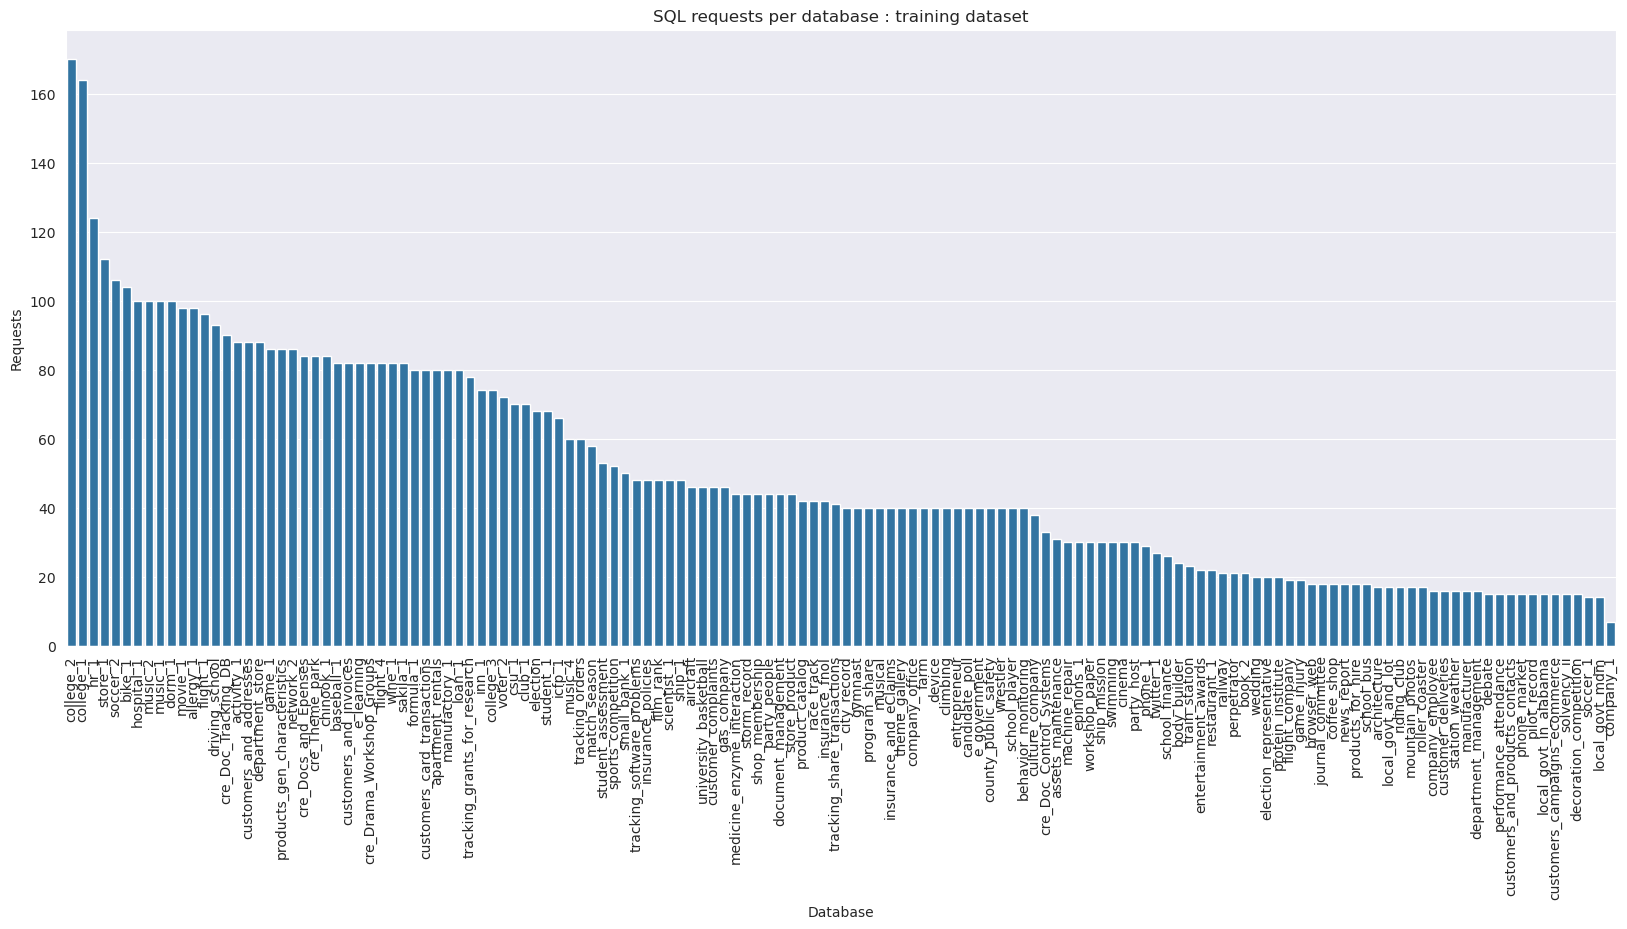

In [11]:
train_db_counts = train_df['db_id'].value_counts()

# Set the figure size
plt.figure(figsize=(20, 8))
# Create a bar plot using Seaborn
sns.barplot(x=train_db_counts.index, y=train_db_counts.values)
# Add labels and title
plt.xlabel('Database')
plt.ylabel('Requests')
plt.title('SQL requests per database : training dataset')
# Rotate x-axis labels for better readability
plt.xticks(rotation=90)
# Show the plot
plt.show()

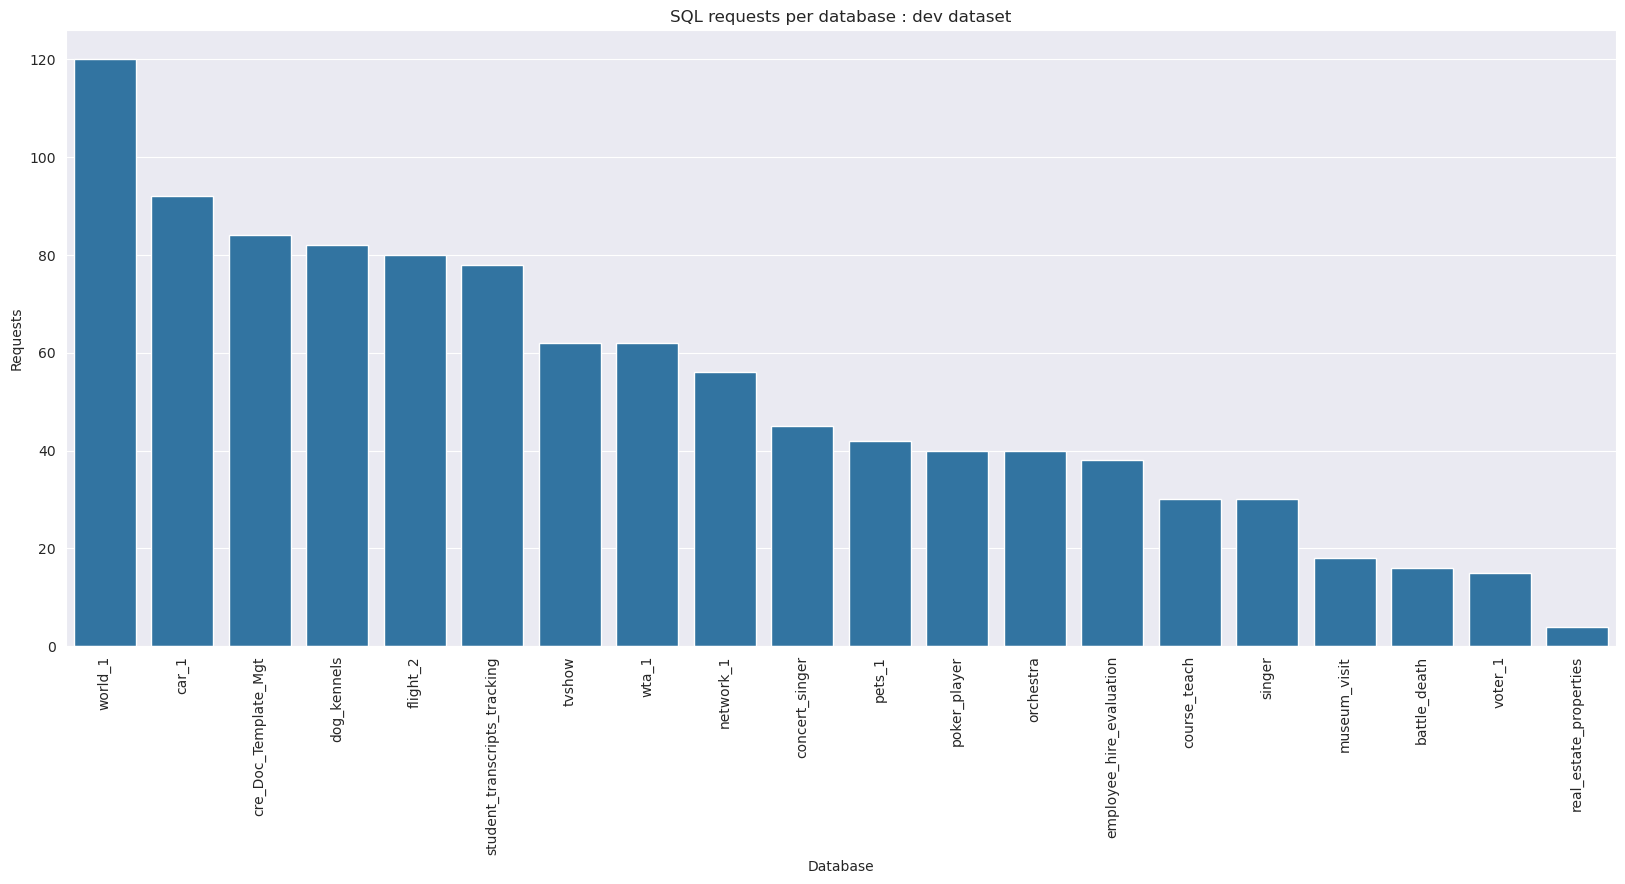

In [12]:
dev_db_counts = dev_df['db_id'].value_counts()

# Set the figure size
plt.figure(figsize=(20, 8))
# Create a bar plot using Seaborn
sns.barplot(x=dev_db_counts.index, y=dev_db_counts.values)
# Add labels and title
plt.xlabel('Database')
plt.ylabel('Requests')
plt.title('SQL requests per database : dev dataset')
# Rotate x-axis labels for better readability
plt.xticks(rotation=90)
# Show the plot
plt.show()

In [13]:
average_train_db_counts = train_db_counts.mean()
average_dev_db_counts = dev_db_counts.mean()

print(f'Average number of requests per database in the training dataset: {average_train_db_counts}')
print(f'Average number of requests per database in the dev dataset: {average_dev_db_counts}')

Average number of requests per database in the training dataset: 50.0
Average number of requests per database in the dev dataset: 51.7


In [17]:
train_longest_query = train_df['question_toks'].apply(len).max()
dev_longest_query = dev_df['question_toks'].apply(len).max()
train_shortest_query = train_df['question_toks'].apply(len).min()
dev_shortest_query = dev_df['question_toks'].apply(len).min()

print(f'Longest question in the training dataset: {train_longest_query}')
print(f'Longest question in the dev dataset: {dev_longest_query}')
print(f'Shortest question in the training dataset: {train_shortest_query}')
print(f'Shortest question in the dev dataset: {dev_shortest_query}')

Longest question in the training dataset: 44
Longest question in the dev dataset: 33
Shortest question in the training dataset: 4
Shortest question in the dev dataset: 5


In [20]:
train_question_mean = train_df['question_toks'].apply(len).mean()
dev_question_mean = dev_df['question_toks'].apply(len).mean()

print(f'Average question size in the training dataset: {train_question_mean}')
print(f'Average question in the dev dataset: {dev_question_mean}')

Average question size in the training dataset: 14.182285714285713
Average question in the dev dataset: 13.743713733075435


In [52]:
import pandas as pd

factual_keywords = [
    "what is", "who is", "where is", "when is", "find", "list", "identify",
    "show", "which", "how much", "how many"
]

comparative_keywords = [
    "which is more", "compare", "greater than", "less than", "better", "worse",
    "higher", "lower", "larger", "smaller", "difference", "versus", "vs"
]

aggregative_keywords = [
    "average", "sum", "total", "count", "maximum", "minimum", "max", "min",
    "median", "mode", "how many", "percentage", "calculate", "ratio"
]

descriptive_keywords = [
    "describe", "explain", "define", "what are", "how does", "why does",
    "reasons", "details of", "elaborate", "overview", "summarize", "outline"
]

procedural_keywords = [
    "how to", "steps to", "process", "procedure", "workflow", "guide",
    "how can", "what is required", "method", "approach", "sequence"
]

evaluative_keywords = [
    "best", "worst", "most", "least", "rank", "evaluate", "assess", "review",
    "determine", "prioritize", "should", "justify", "why"
]

def categorize_question(question):
    if isinstance(question, str):
        question = question.lower()
        if any(keyword in question for keyword in factual_keywords):
            return "Factual"
        elif any(keyword in question for keyword in comparative_keywords):
            return "Comparative"
        elif any(keyword in question for keyword in aggregative_keywords):
            return "Aggregative"
        elif any(keyword in question for keyword in descriptive_keywords):
            return "Descriptive"
    return "Other"

def categorize_questions_list(questions):
    categorized_data = [{'question': question, 'category': categorize_question(question)} for question in questions]
    return pd.DataFrame(categorized_data)

In [53]:
test1 = dev_df['question']
test = train_df['question']
t = pd.concat([train_df['question'], dev_df['question']], axis=0).reset_index(drop=True)
categorized_questions = categorize_questions_list(t)

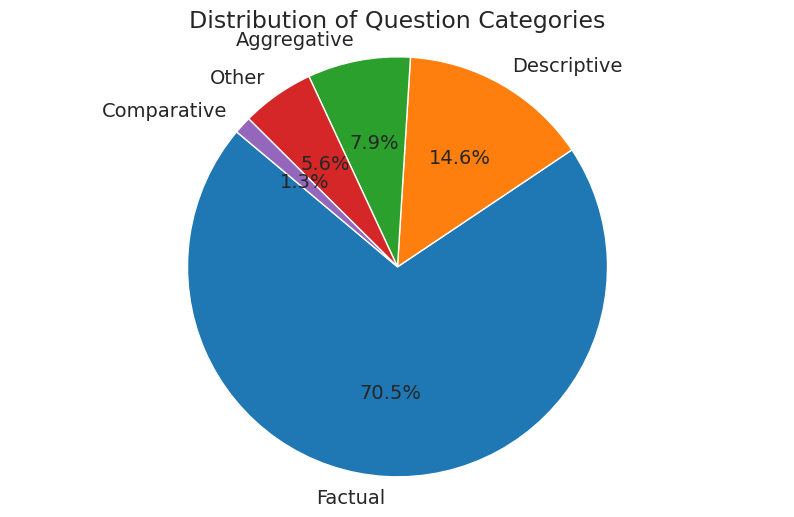

In [55]:
import matplotlib.pyplot as plt

# Count the occurrences of each category
category_counts = categorized_questions['category'].value_counts()

# Create a pie chart with larger text
plt.figure(figsize=(10, 6))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 14})
plt.title('Distribution of Question Categories', fontsize=17)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [56]:
from collections import Counter
import pandas as pd

# Combine all questions into a single list
all_questions = pd.concat([train_df['question'], dev_df['question']], axis=0).reset_index(drop=True)

# Tokenize the questions
all_tokens = [token for question in all_questions for token in question.split()]

# Count unique tokens
vocabulary_size = len(set(all_tokens))

print(f'Vocabulary size of all questions: {vocabulary_size}')

Vocabulary size of all questions: 7818


In [58]:
all_queries = pd.concat([train_df['query'], dev_df['query']], axis=0).reset_index(drop=True)

'SELECT count(*) FROM head WHERE age  >  56'

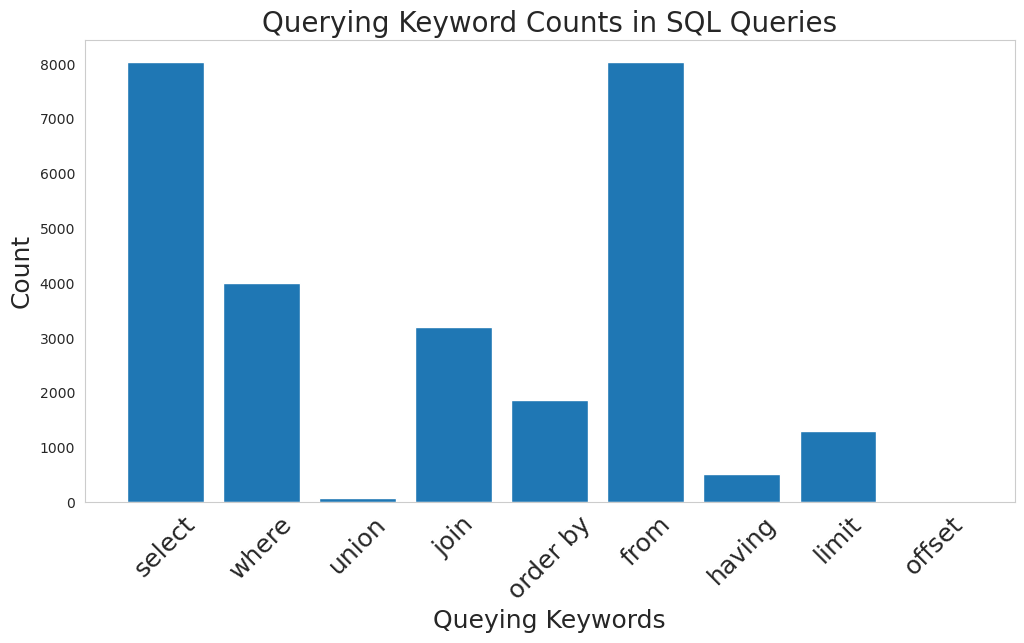

In [88]:
import matplotlib.pyplot as plt

# Define the keywords to search for
keywords = ["select", "where", "union", "join", "order by", "from", "having", "limit", "offset"]

# Combine all queries into a single list
all_queries = pd.concat([train_df['query'], dev_df['query']], axis=0).reset_index(drop=True)

# Function to count occurrences of each keyword in the queries
def count_keywords(queries, keywords):
    keyword_counts = {keyword: 0 for keyword in keywords}
    for query in queries:
        query = query.lower()
        for keyword in keywords:
            if keyword in query:
                keyword_counts[keyword] += 1
    return keyword_counts

# Count the occurrences of each keyword
keyword_counts = count_keywords(all_queries, keywords)

# Plot the histogram
plt.figure(figsize=(12, 6))
plt.bar(keyword_counts.keys(), keyword_counts.values())
plt.xlabel('Queying Keywords', fontsize=18)
plt.ylabel('Count', fontsize=18)
plt.title('Querying Keyword Counts in SQL Queries', fontsize=20)
plt.xticks(rotation=45, fontsize=18)
plt.grid(False)
plt.show()

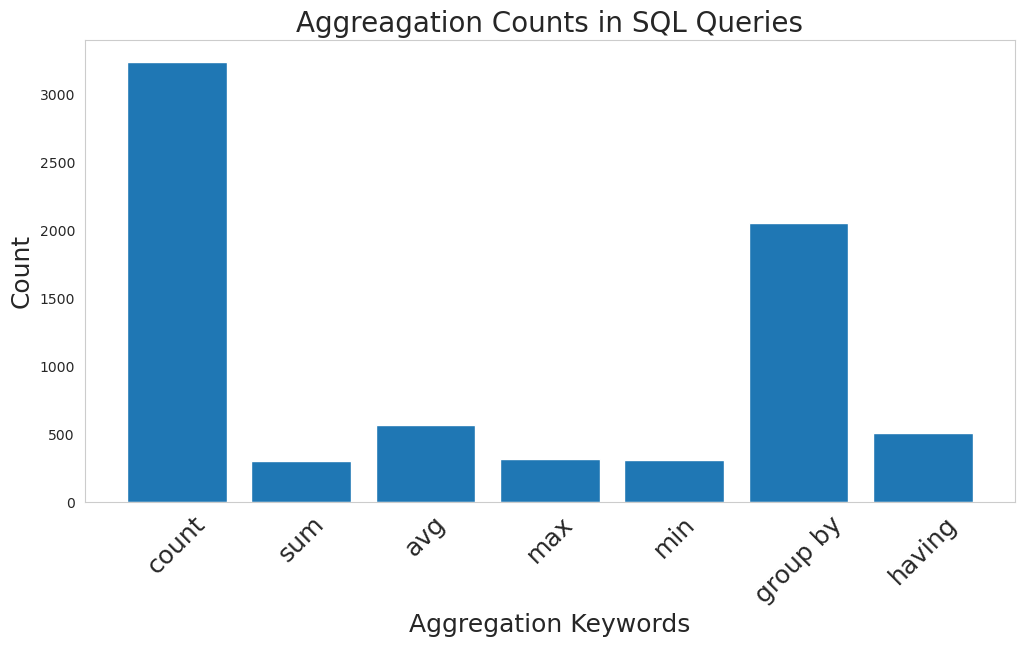

In [87]:
aggregation_keywords = [
    "COUNT", "SUM", "AVG", "MAX", "MIN", "GROUP BY", "HAVING"
]

aggregation_keywords = [keyword.lower() for keyword in aggregation_keywords]
# Count the occurrences of each keyword
keyword_counts = count_keywords(all_queries, aggregation_keywords)

# Plot the histogram
plt.figure(figsize=(12, 6))
plt.bar(keyword_counts.keys(), keyword_counts.values())
plt.xlabel('Aggregation Keywords', fontsize=18)
plt.ylabel('Count', fontsize=18)
plt.title('Aggreagation Counts in SQL Queries', fontsize=20)
plt.xticks(rotation=45, fontsize=18)
plt.grid(False)
plt.show()

In [89]:
import pandas as pd

# Combine all queries into a single list
all_queries = pd.concat([train_df['query'], dev_df['query']], axis=0).reset_index(drop=True)

# Function to count nested queries and subqueries
def count_nested_queries(queries):
    nested_query_count = 0
    for query in queries:
        query = query.lower()
        if query.count('select') > 1:
            nested_query_count += 1
    return nested_query_count

# Count the occurrences of nested queries
nested_query_count = count_nested_queries(all_queries)

print(f'Number of queries containing nested queries or subqueries: {nested_query_count}')

Number of queries containing nested queries or subqueries: 1178


In [101]:
import re
import pandas as pd

# Function to count the number of columns in a CREATE TABLE statement
def count_columns_in_table(create_table_statement):
    # Use regular expression to find all column definitions
    columns = re.findall(r'\n\s*"\w+"', create_table_statement)
    return len(columns)

# Function to count the number of columns in the schema
def count_columns_in_schema(schema):
    # Use regular expression to find all CREATE TABLE statements
    create_table_statements = re.findall(r'CREATE TABLE.*?\((.*?)\);', schema, re.DOTALL | re.IGNORECASE)
    column_count = sum(count_columns_in_table(statement) for statement in create_table_statements)
    return column_count

# Function to count columns for all databases and calculate the average
def avg_columns_in_all_databases(df):
    column_counts = []
    for index, row in df.iterrows():
        schema = row['schema']
        column_count = count_columns_in_schema(schema)
        column_counts.append(column_count)
    avg_column_count = sum(column_counts) / len(column_counts) if column_counts else 0
    return avg_column_count

# Load the table descriptions
table_df = pd.read_json('data/tables_description.json')

# Calculate the average number of columns
average_column_count = avg_columns_in_all_databases(table_df)

print(f'Average number of columns across all databases: {average_column_count}')

Average number of columns across all databases: 10.120481927710843


In [9]:
dev_db = dev_df['db_id']
print(dev_db.unique())

['concert_singer' 'pets_1' 'car_1' 'flight_2' 'employee_hire_evaluation'
 'cre_Doc_Template_Mgt' 'course_teach' 'museum_visit' 'wta_1'
 'battle_death' 'student_transcripts_tracking' 'tvshow' 'poker_player'
 'voter_1' 'world_1' 'orchestra' 'network_1' 'dog_kennels' 'singer'
 'real_estate_properties']


In [28]:
"""
import json
tables_description_enhanced = [{"db_id": db_id, "schea": ""} for db_id in dev_db.unique()]
# Save the list to a JSON file
with open('data/tables_description_enhanced.json', 'w') as file:
    json.dump(tables_description_enhanced, file, indent=4)
"""